# Evaluation

## Objective
เพื่อประเมินว่า Random Forest Model สามารถช่วยตัดสินใจในเชิงธุรกิจได้จริงมั้ย
โดยพิจารณาทั้ง:
- ความแม่นยำของ Model (Accuracy, F1-score, ROC-AUC)
- ความสามารถในการลดการตัดสินใจผิดพลาดที่กระทบธุรกิจ เช่น FP, FN
- ความสามารถในการนำไปใช้งานจริง (Generalization)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.model_selection import cross_val_score

In [5]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

best_model = joblib.load("../models/best_model_random_forest.pkl")

print(f"Model loaded: {best_model.__class__.__name__}")

Model loaded: RandomForestClassifier


## 1. Generate Predictions   
สร้าง Predictions บน Train set และ Test set เพื่อเปรียบเทียบ

In [6]:
# Predict class labels
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

# Predict probabilities
y_prob_train = best_model.predict_proba(X_train)[:, 1]
y_prob_test  = best_model.predict_proba(X_test)[:, 1]

print(pd.DataFrame({
    "Actual": y_test[:10].values,
    "Predicted": y_pred_test[:10]
}))

   Actual  Predicted
0       0          1
1       1          0
2       1          0
3       1          1
4       0          1
5       0          1
6       0          0
7       0          0
8       1          1
9       0          1


**Insights**   
Model สามรถทำนายได้ทั้ง class 0/1 และ probability ได้ จะพบว่าจาก sample มี Model สามารถจับ pattern ได้บางส่วน เเสดงว่า model ยังมี uncertainty ในบาง case

## 2. Accuracy, Precision, Recall, F1
ดูการทำงานของ Testing Data กับข้อมูลใหม่ที่ไม่เคยเห็น

In [7]:
# Core metrics
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)
test_auc  = roc_auc_score(y_test, y_prob_test)

gap = train_acc - test_acc

print(f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | AUC: {test_auc:.4f}")
print(f"Overfit: {'Yes' if gap > 0.10 else 'No'}")

print("Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=["Low", "High"]))

Train Acc: 0.7801 | Test Acc: 0.6154 | AUC: 0.6543
Overfit: Yes
Classification Report:
              precision    recall  f1-score   support

         Low       0.59      0.75      0.66        85
        High       0.66      0.48      0.55        84

    accuracy                           0.62       169
   macro avg       0.62      0.61      0.61       169
weighted avg       0.62      0.62      0.61       169



**Insights**    
- **Performance** โดยรวมของ Model (Test Acc: 0.6154 และ AUC: 0.6543) จะเห็นว่า Model สามารถแยก High/Low commission ได้ดีในระดับปานกลาง
- จาก Train Acc: 0.7801 และ Test Acc: 0.6154 มี gap ค่อนข้างสูง แสดงว่า model มีแนวโน้ม **overfitting** โดยสามารถจดจำ pattern ใน training data ได้ดี แต่ performance ลดลงเมื่อเจอข้อมูลใหม่
- ถ้าดูตาม **class** พบว่า Model มี Recall ของ High เพียง 0.48 แสดงว่ายังไม่สามารถตรวจจับสินค้าที่มีโอกาสทำ commission สูงได้ดีพอ ส่งผลให้เกิด False Negative สูง (พลาดโอกาสทำรายได้) ในขณะที่ Recall ของ Low อยู่ที่ 0.75 แสดงว่า Model สามารถหลีกเลี่ยงสินค้าที่ไม่ทำเงินได้ดี

## 3. Confusion Matrix
ดูภาพรวมว่า Model ทายถูก/ผิดประเภทไหนมากที่สุด

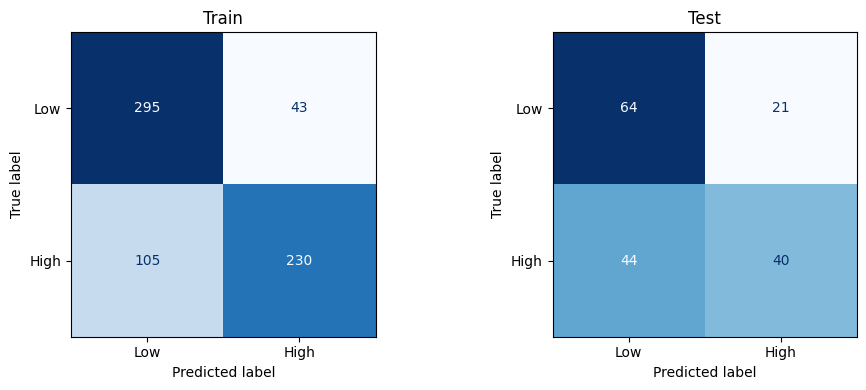

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_train, y_pred_train, "Train"), (y_test, y_pred_test, "Test")]
):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Low", "High"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

**Insights**   
- **Confusion Matrix ของ Train set** พบว่า Model สามารถทำนาย Low ได้ค่อนข้างดี (295) และมีการทำนายผิดเป็น High จำนวน 43 ตัว สำหรับ High commission Model ทำนายถูก 230 จาก 335 แต่ยังมีการทำนายผิดเป็น Low ถึง 105 cases
- **Confusion Matrix ของ Test set** พบว่า Model สามารถทำนาย Low ได้ค่อนข้างดี (64 จาก 85) แต่ยังมีการทำนายผิดเป็น High อยู่บ้าง (21) ในขณะที่ High commission ซึ่งเป็นกลุ่มที่สำคัญต่อธุรกิจ Model ทำนายถูกเพียง 40 จาก 84 และพลาดไปถึง 44 ตัว

## 4. ROC Curve & AUC Score
วัดความสามารถในการแยก High vs Low Commission ของ Model

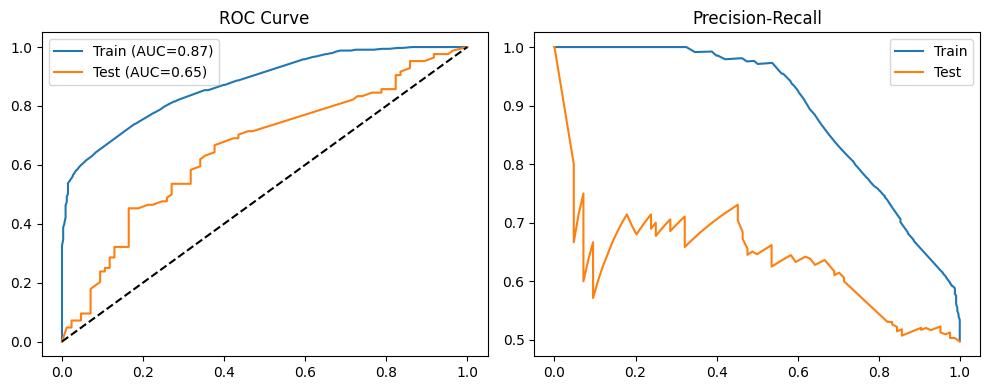

In [9]:
train_auc = roc_auc_score(y_train, y_prob_train)
test_auc  = roc_auc_score(y_test, y_prob_test)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ROC Curve
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_prob_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_prob_test)

axes[0].plot(fpr_tr, tpr_tr, label=f"Train (AUC={train_auc:.2f})")
axes[0].plot(fpr_te, tpr_te, label=f"Test (AUC={test_auc:.2f})")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall Curve
prec_tr, rec_tr, _ = precision_recall_curve(y_train, y_prob_train)
prec_te, rec_te, _ = precision_recall_curve(y_test,  y_prob_test)

axes[1].plot(rec_tr, prec_tr, label="Train")
axes[1].plot(rec_te, prec_te, label="Test")
axes[1].set_title("Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

**Insights**   
- **ROC Curve**   
    Train AUC = 0.87 แต่ Test AUC = 0.65 ลดลงชัดเจน  
    แสดงว่า model แยก High vs Low ได้ดีใน training data แต่ performance ลดลงเมื่อเจอข้อมูลใหม่ก็คือมี overfitting แสดงmodel ยังแยกกลุ่มได้แต่ไม่แม่นมาก
- **Precision-Recall**   
    เส้น Train อยู่สูงกว่า Test อย่างชัดเจน แสดงว่า model ทำได้ดีใน training แต่ performance ไม่เสถียรใน test แสดงว่า Model จับ High commission ได้ไม่ดีพอโดยเฉพาะในบาง threshold

## 5. Feature Importance Analysis
ดูว่า Feature ไหนมีผลต่อการ Predict commission_level มากที่สุด

Top Features:
click_hour                   0.466183
click_day_of_week            0.288719
Sub_id1_colgateOpticWhite    0.039534
Sub_id2_purple               0.033881
Sub_id1_nude                 0.033165
dtype: float64


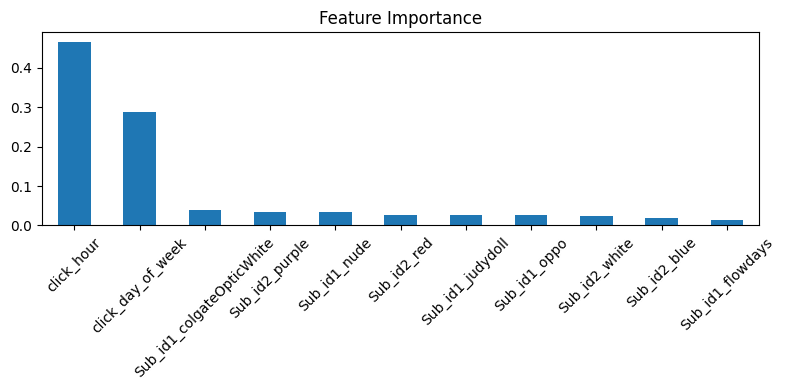

In [10]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top Features:")
print(feat_imp.head())

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights**   
Feature ที่มีผลต่อการทำนายสุดคือ click_hour เเล้วรองลงมาคือ click_day_of_week เเสดงว่าเวลาเป็นปัจจัยหลักในการกำหนดโอกาสที่จะได้ High Commission   
ในขณะที่ feature สินค้าและกลุ่ม facebook model จะมองว่ามันมีผลรองลงมา
สรุปก็คือการเลือกเวลาฌพสต์มีผลต่อรายได้มากกว่าการเลือกสินค้า/กลุ่ม facebook

## 6. Check Overfitting using Cross-Validation

In [11]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)

print(f"CV Mean: {cv_scores.mean():.4f}")
print(f"Test Acc: {test_acc:.4f}")

if abs(cv_scores.mean() - test_acc) <= 0.05:
    print("Good generalization")
else:
    print("Possible overfitting")

CV Mean: 0.6018
Test Acc: 0.6154
Good generalization


**Insights**    
ค่า CV มีค่าใกล้เคียงกับ Test Accuracy เเสดงว่า model มี generalization ที่ดีและ performance แม้ว่าก่อนหน้านี้จะพบ overfitting แต่จาก CV ทำให้มั่นใจได้ว่า model ยังมีความ stable และใช้งานกับข้อมูลใหม่ได้พอสมควร